In [2]:
# WED VS HMS


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6250 - loss: 0.9134 - precision_4: 0.7500 - recall_4: 0.6000 - val_accuracy: 0.6667 - val_loss: 4.3550 - val_precision_4: 1.0000 - val_recall_4: 0.5000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step - accuracy: 1.0000 - loss: 2.3186e-04 - precision_4: 1.0000 - recall_4: 1.0000 - val_accuracy: 0.6667 - val_loss: 6.0479 - val_precision_4: 1.0000 - val_recall_4: 0.5000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - accuracy: 1.0000 - loss: 1.0674e-19 - precision_4: 1.0000 - recall_4: 1.0000 - val_accuracy: 0.6667 - val_loss: 7.2264 - val_precision_4: 1.0000 - val_recall_4: 0.5000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step - accuracy: 1.0000 - loss: 2.0027e-24 - precision_4: 1.0000 - recall_4: 1.0000 - val_accuracy: 0.6667 - val_loss: 8.0860 - val_precision_4: 1.0000 - val_recall_4: 0.5000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step - accuracy: 1.0000 - loss: 2.8272e-24 - precision_4: 1.0000 - recall_4: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
  Sample_Name  Actual  Predicted
0        YG10     1.0        1.0
1        PJ22     1.0        1.0
2       21114     0.0        0.0
3       19543     0.0        0.0
4       21017     0.0        0.0


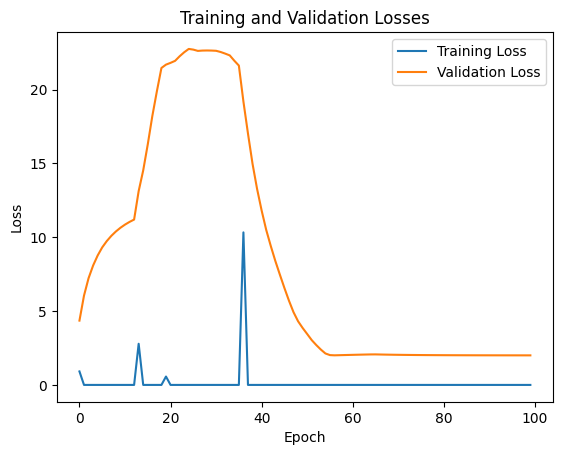

[[4 0]
 [0 2]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         4
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/HMS VS WED(ch)transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


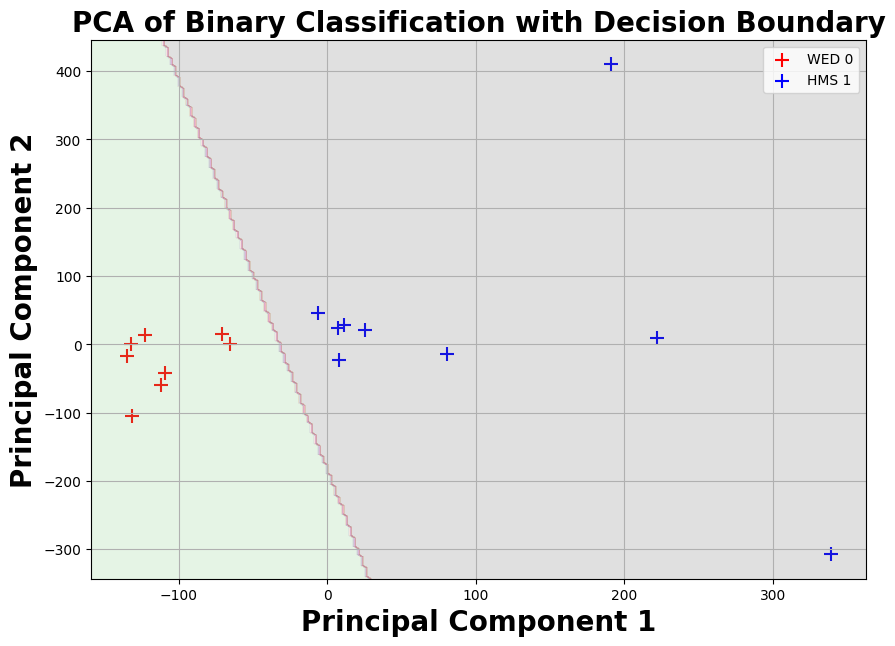

Explained variance ratio by each principal component:
[0.08042408 0.07386456]


KeyError: "['Classification'] not found in axis"

In [41]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Apply PCA to the features
pca = PCA(n_components=2)  # Use 2 components for visualization
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with PCA results and the target variable
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Classification'] = Y

# Train a Logistic Regression model on the PCA components
lr = LogisticRegression()
lr.fit(X_pca, Y)

# Plot the principal components, color-coded by the binary classes
plt.figure(figsize=(10, 7))
for class_value, label, color in zip(pca_df['Classification'].unique(), ['WED 0', 'HMS 1'], ['red', 'blue']):
    subset = pca_df[pca_df['Classification'] == class_value]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, color=color, marker='+', s=100)

# Plot decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 200), np.linspace(ylim[0], ylim[1], 200))
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.2, cmap='Accent')
plt.xlabel('Principal Component 1', fontsize=20, weight='bold')
plt.ylabel('Principal Component 2', fontsize=20, weight='bold')
plt.title('PCA of Binary Classification with Decision Boundary', fontsize=20, weight='bold')
plt.legend()
plt.grid()

# Save the plot with a white background and high DPI
plt.savefig('/content/PCA_decision_boundary.png', dpi=300, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

# Print explained variance ratio
print("Explained variance ratio by each principal component:")
print(pca.explained_variance_ratio_)

# Mapping the principal components to original feature names
feature_names = data.drop(columns=[target_column]).columns
components_df = pd.DataFrame(pca.components_, columns=feature_names, index=['PC1', 'PC2'])

# Display the principal components dataframe
print("Principal components (loadings):")
print(components_df)

# Save the principal components to a CSV file if needed
components_df.to_csv('/content/principal_components_loadings.csv', index=True)


**HMS VS WED WITHOUT SEX CHROMOSOME:
**




/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6250 - loss: 0.7564 - precision_1: 0.7500 - recall_1: 0.6000 - val_accuracy: 0.3333 - val_loss: 2.7826 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0813 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.6906 - val_precision_1: 1.0000 - val_recall_1: 0.5000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step - accuracy: 1.0000 - loss: 7.8011e-34 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.1210 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step - accuracy: 1.0000 - loss: 3.8645e-22 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0265 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step - accuracy: 1.0000 - loss: 8.3743e-19 - precision_1: 1.0000 - recall_1:

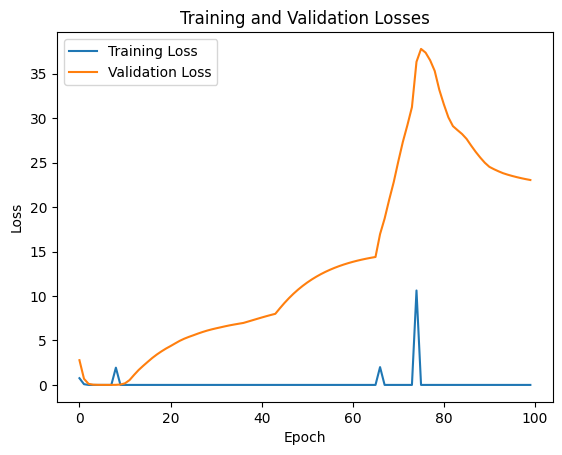

[[4 0]
 [1 1]]
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         4
         1.0       1.00      0.50      0.67         2

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/HMS VS WED(wxy)transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


<ipython-input-37-c5c81e32ed42>:59: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


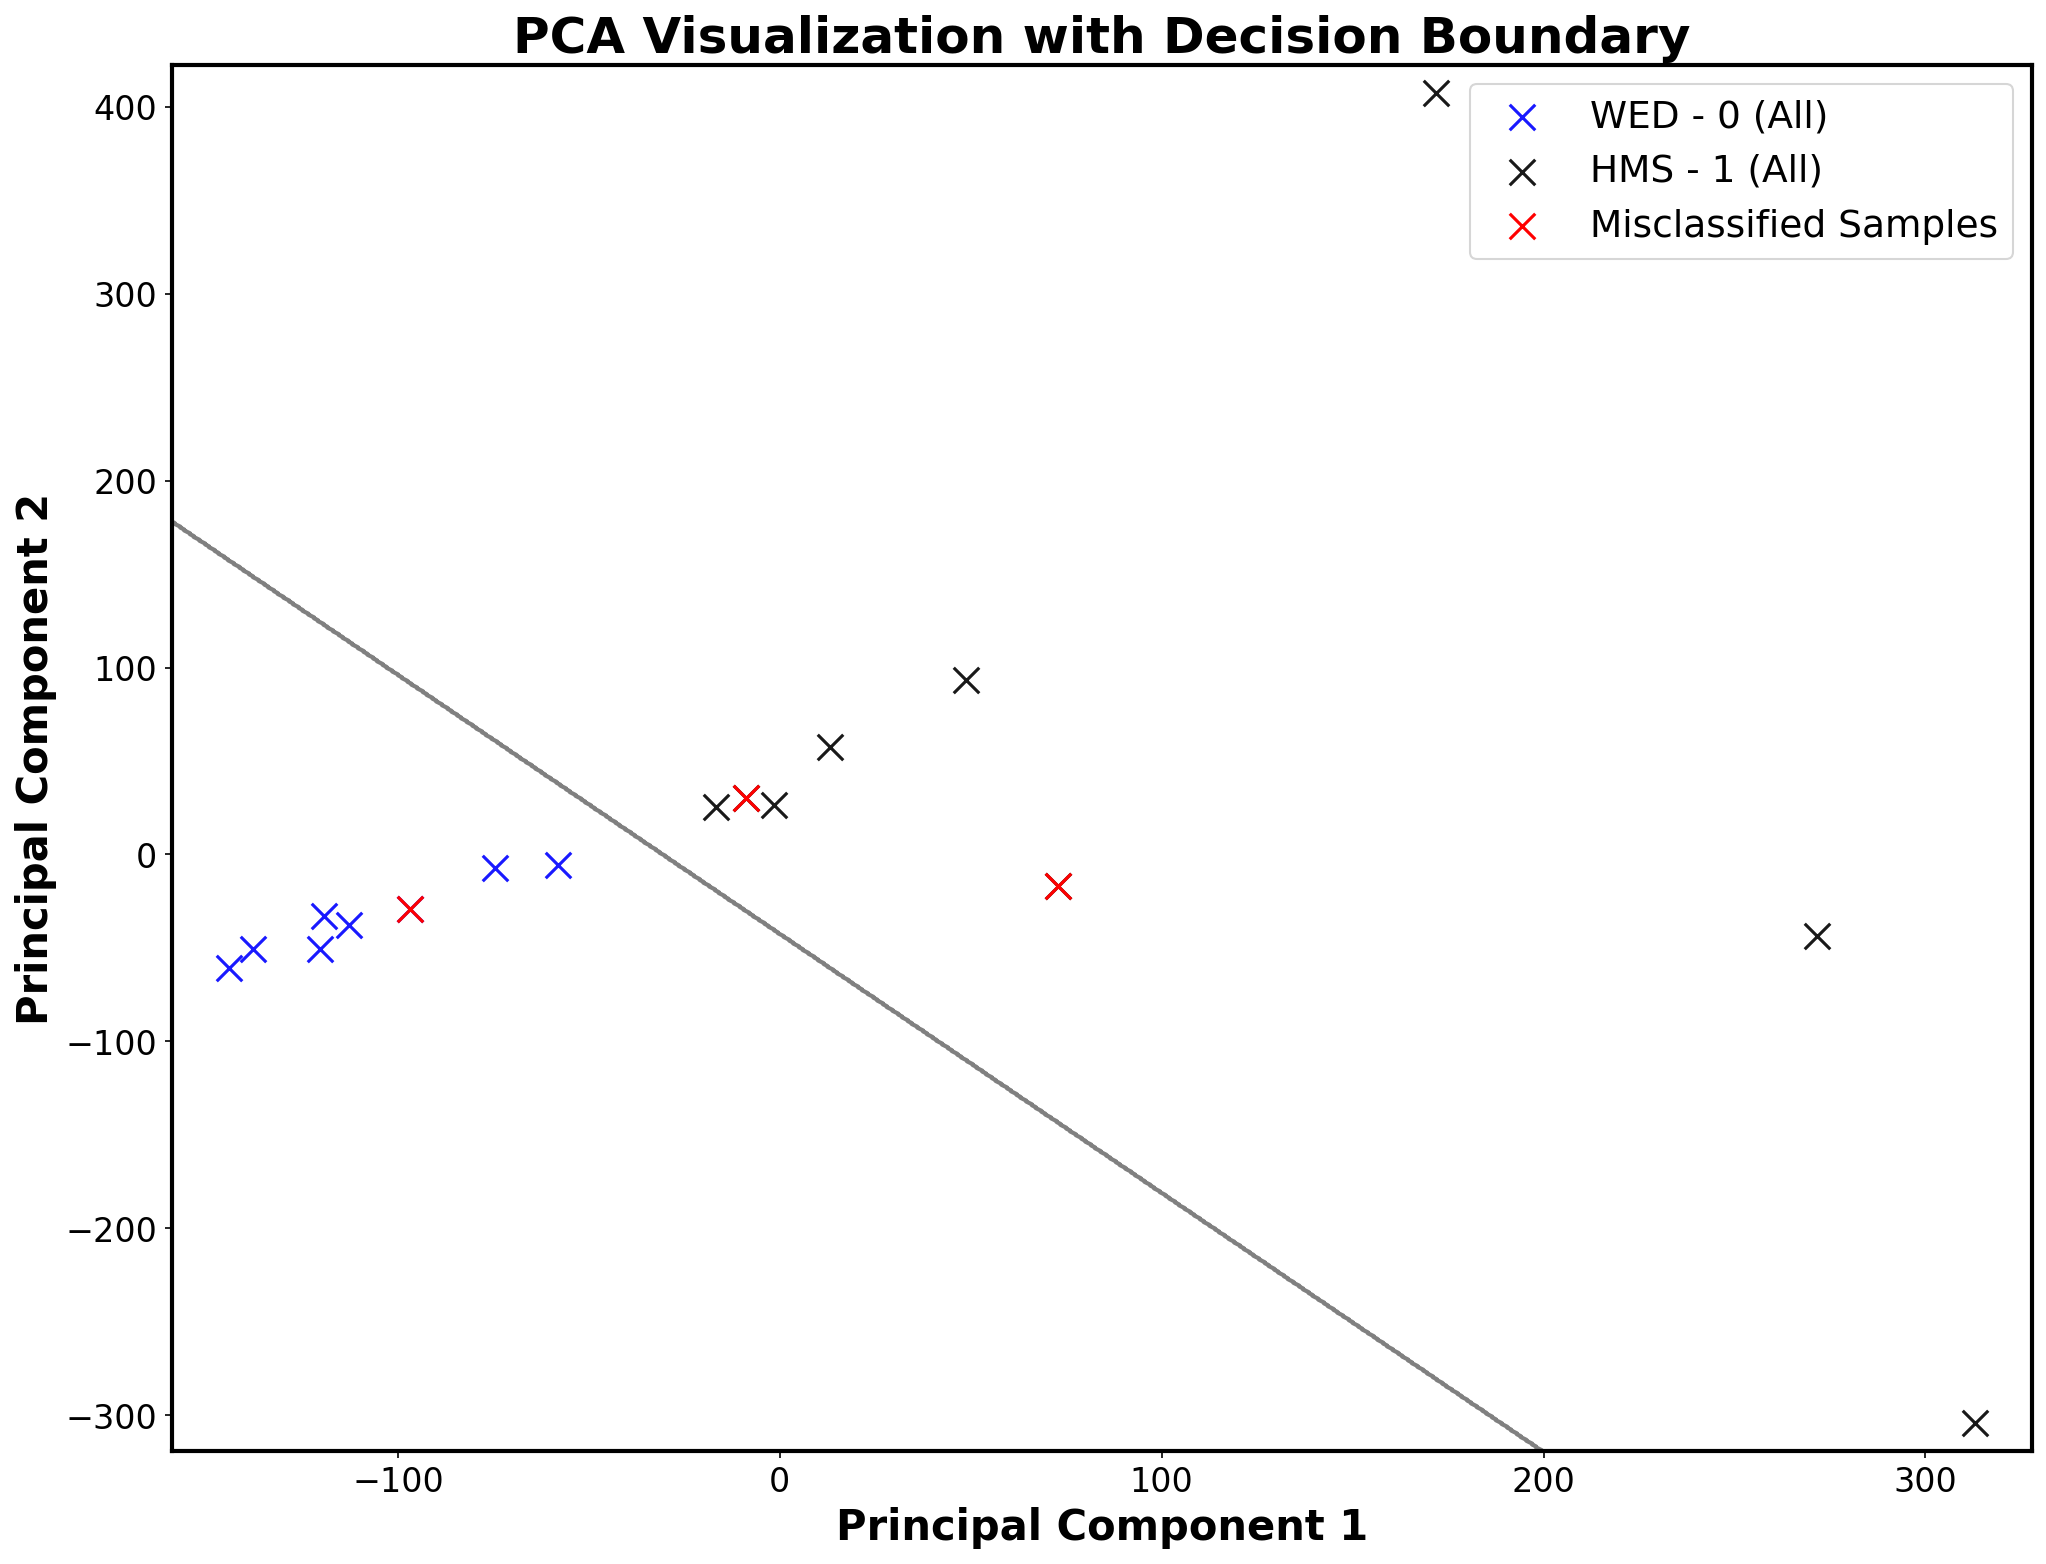

In [37]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Perform PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Map train and test indices to boolean masks
train_indices_bool = np.isin(indices, train_indices)
test_indices_bool = np.isin(indices, test_indices)

# Separate PCA-reduced train and test data
X_pca_train = X_pca[train_indices_bool]
X_pca_test = X_pca[test_indices_bool]
Y_train_subset = Y[train_indices_bool]
Y_test_subset = Y[test_indices_bool]

# Identify misclassified samples within the test set
misclassified_test_indices = np.where((Y_test_subset != Y_pred_classes.flatten()))[0]
misclassified_pca = X_pca_test[misclassified_test_indices]

# Create a mesh grid for the decision boundary
x_min, x_max = X_pca[:, 0].min() - 15, X_pca[:, 0].max() + 15  # Extend range significantly
y_min, y_max = X_pca[:, 1].min() - 15, X_pca[:, 1].max() + 15
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                     np.arange(y_min, y_max, 0.5))

# Train a classifier (e.g., Logistic Regression) for decision boundary
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_pca, Y)  # Combine train and test for the boundary

# Predict the decision boundary
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary with a fully white background
fig, ax = plt.subplots(figsize=(16, 12), dpi=150)  # HD resolution with larger figure
ax.contour(xx, yy, Z, levels=[0.5], colors='gray', linewidths=2)  # Decision boundary as a clean gray line

# Set the entire plot and surrounding area to white
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot all WED (0) samples (train and test)
ax.scatter(
    X_pca[Y == 0, 0], X_pca[Y == 0, 1],
    color='blue', marker='x', label='WED - 0 (All)', alpha=0.9, s=150
)

# Plot all HMS (1) samples (train and test)
ax.scatter(
    X_pca[Y == 1, 0], X_pca[Y == 1, 1],
    color='black', marker='x', label='HMS - 1 (All)', alpha=0.9, s=150
)

# Highlight misclassified samples with a red cross
ax.scatter(
    misclassified_pca[:, 0], misclassified_pca[:, 1],
    color='red', marker='x', edgecolor='black', s=150, label='Misclassified Samples'
)

# Add a box boundary around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')  # Set the color of the box boundary
    spine.set_linewidth(2)        # Set the width of the box boundary

# Add title, labels, and legend with larger font sizes
ax.set_title('PCA Visualization with Decision Boundary', fontsize=24, weight='bold')
ax.set_xlabel('Principal Component 1', fontsize=20, weight='bold')
ax.set_ylabel('Principal Component 2', fontsize=20, weight='bold')
ax.legend(fontsize=18, loc='upper right')

# Make tick labels larger
ax.tick_params(axis='both', which='major', labelsize=16)

# Set explicit plot range
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Save the plot as a high-resolution image
plt.savefig("PCA_Visualization_HD.png", dpi=300, bbox_inches='tight', facecolor='white')  # Save with a white background

# Show the plot
plt.show()


**NES VS HMS WITH X,Y CHOROMOSOME**

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8750 - loss: 0.3736 - precision_3: 0.8333 - recall_3: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.2335 - val_precision_3: 1.0000 - val_recall_3: 0.5000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step - accuracy: 1.0000 - loss: 1.3465e-15 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0892 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step - accuracy: 1.0000 - loss: 6.5109e-35 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0313 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step - accuracy: 1.0000 - loss: 7.3446e-16 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0111 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_3: 1.0000 - recall_3: 1.0

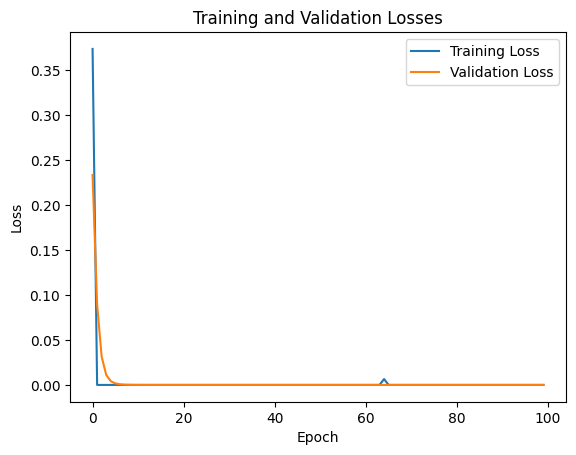

[[3 0]
 [0 2]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         3
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [43]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES VS HMS(ch)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


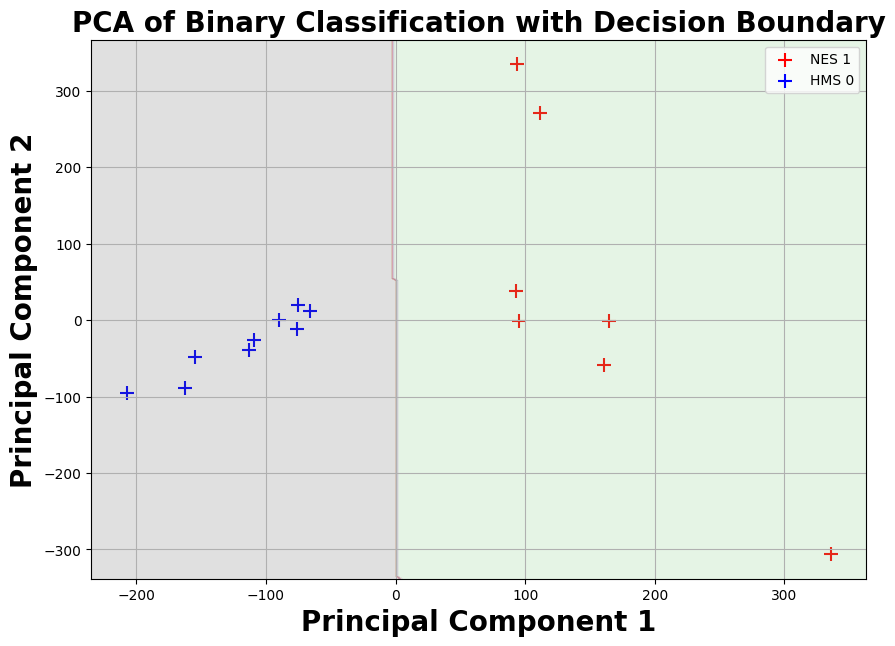

Explained variance ratio by each principal component:
[0.09015113 0.07972091]
Principal components (loadings):
     Scaffold_1.42470  Scaffold_1.42483  Scaffold_1.42490  Scaffold_1.42491  \
PC1         -0.000327          0.001108          0.001175          0.001055   
PC2         -0.001765          0.004508         -0.000249          0.000532   

     Scaffold_1.42492  Scaffold_1.42494  Scaffold_1.42505  Scaffold_1.42507  \
PC1          0.003084          0.000167          0.002401          0.000545   
PC2         -0.000802         -0.001259         -0.001297          0.000887   

     Scaffold_1.42510  Scaffold_1.42512  ...  Scaffold_Y.2625978  \
PC1         -0.001349          0.000681  ...            0.001176   
PC2         -0.002726         -0.001296  ...           -0.000249   

     Scaffold_Y.2625989  Scaffold_Y.2625990  Scaffold_Y.2625999  \
PC1           -0.000949           -0.001090           -0.001134   
PC2           -0.000320            0.000215            0.001879   

     S

In [48]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Apply PCA to the features
pca = PCA(n_components=2)  # Use 2 components for visualization
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with PCA results and the target variable
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Classification'] = Y

# Train a Logistic Regression model on the PCA components
lr = LogisticRegression()
lr.fit(X_pca, Y)

# Plot the principal components, color-coded by the binary classes
plt.figure(figsize=(10, 7))
for class_value, label, color in zip(pca_df['Classification'].unique(), ['NES 1', 'HMS 0'], ['red', 'blue']):
    subset = pca_df[pca_df['Classification'] == class_value]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, color=color, marker='+', s=100)

# Plot decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 200), np.linspace(ylim[0], ylim[1], 200))
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.2, cmap='Accent')
plt.xlabel('Principal Component 1', fontsize=20, weight='bold')
plt.ylabel('Principal Component 2', fontsize=20, weight='bold')
plt.title('PCA of Binary Classification with Decision Boundary', fontsize=20, weight='bold')
plt.legend()
plt.grid()

# Save the plot with a white background and high DPI
plt.savefig('/content/PCA_decision_boundary.png', dpi=300, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

# Print explained variance ratio
print("Explained variance ratio by each principal component:")
print(pca.explained_variance_ratio_)

# Mapping the principal components to original feature names
feature_names = data.drop(columns=[target_column]).columns
components_df = pd.DataFrame(pca.components_, columns=feature_names, index=['PC1', 'PC2'])

# Display the principal components dataframe
print("Principal components (loadings):")
print(components_df)

# Save the principal components to a CSV file if needed
components_df.to_csv('/content/principal_components_loadings.csv', index=True)


NES VS HMS WITHOUT XY CHROMOSOME

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2500 - loss: 1.0402 - precision_4: 0.3333 - recall_4: 0.2000 - val_accuracy: 1.0000 - val_loss: 5.9040e-07 - val_precision_4: 1.0000 - val_recall_4: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 1.6016e-22 - precision_4: 1.0000 - recall_4: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.1813e-09 - val_precision_4: 1.0000 - val_recall_4: 1.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 876ms/step - accuracy: 1.0000 - loss: 1.4390e-10 - precision_4: 1.0000 - recall_4: 1.0000 - val_accuracy: 1.0000 - val_loss: 2.4394e-11 - val_precision_4: 1.0000 - val_recall_4: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step - accuracy: 1.0000 - loss: 1.5301e-27 - precision_4: 1.0000 - recall_4: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.7402e-12 - val_precision_4: 1.0000 - val_recall_4: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - accuracy: 1.0000 - loss: 1.2905e-33 - precision_4: 1.0000

Loss: 8.155605447440053e-18
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
  Sample_Name  Actual  Predicted
0        1774     0.0        0.0
1        1838     0.0        0.0
2        LJ20     1.0        1.0
3        YG10     1.0        1.0
4       3747S     0.0        0.0


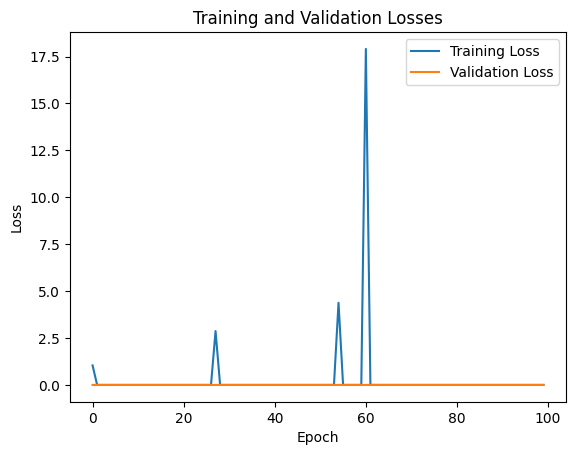

[[3 0]
 [0 2]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         3
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [49]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES VS HMS(wxy)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


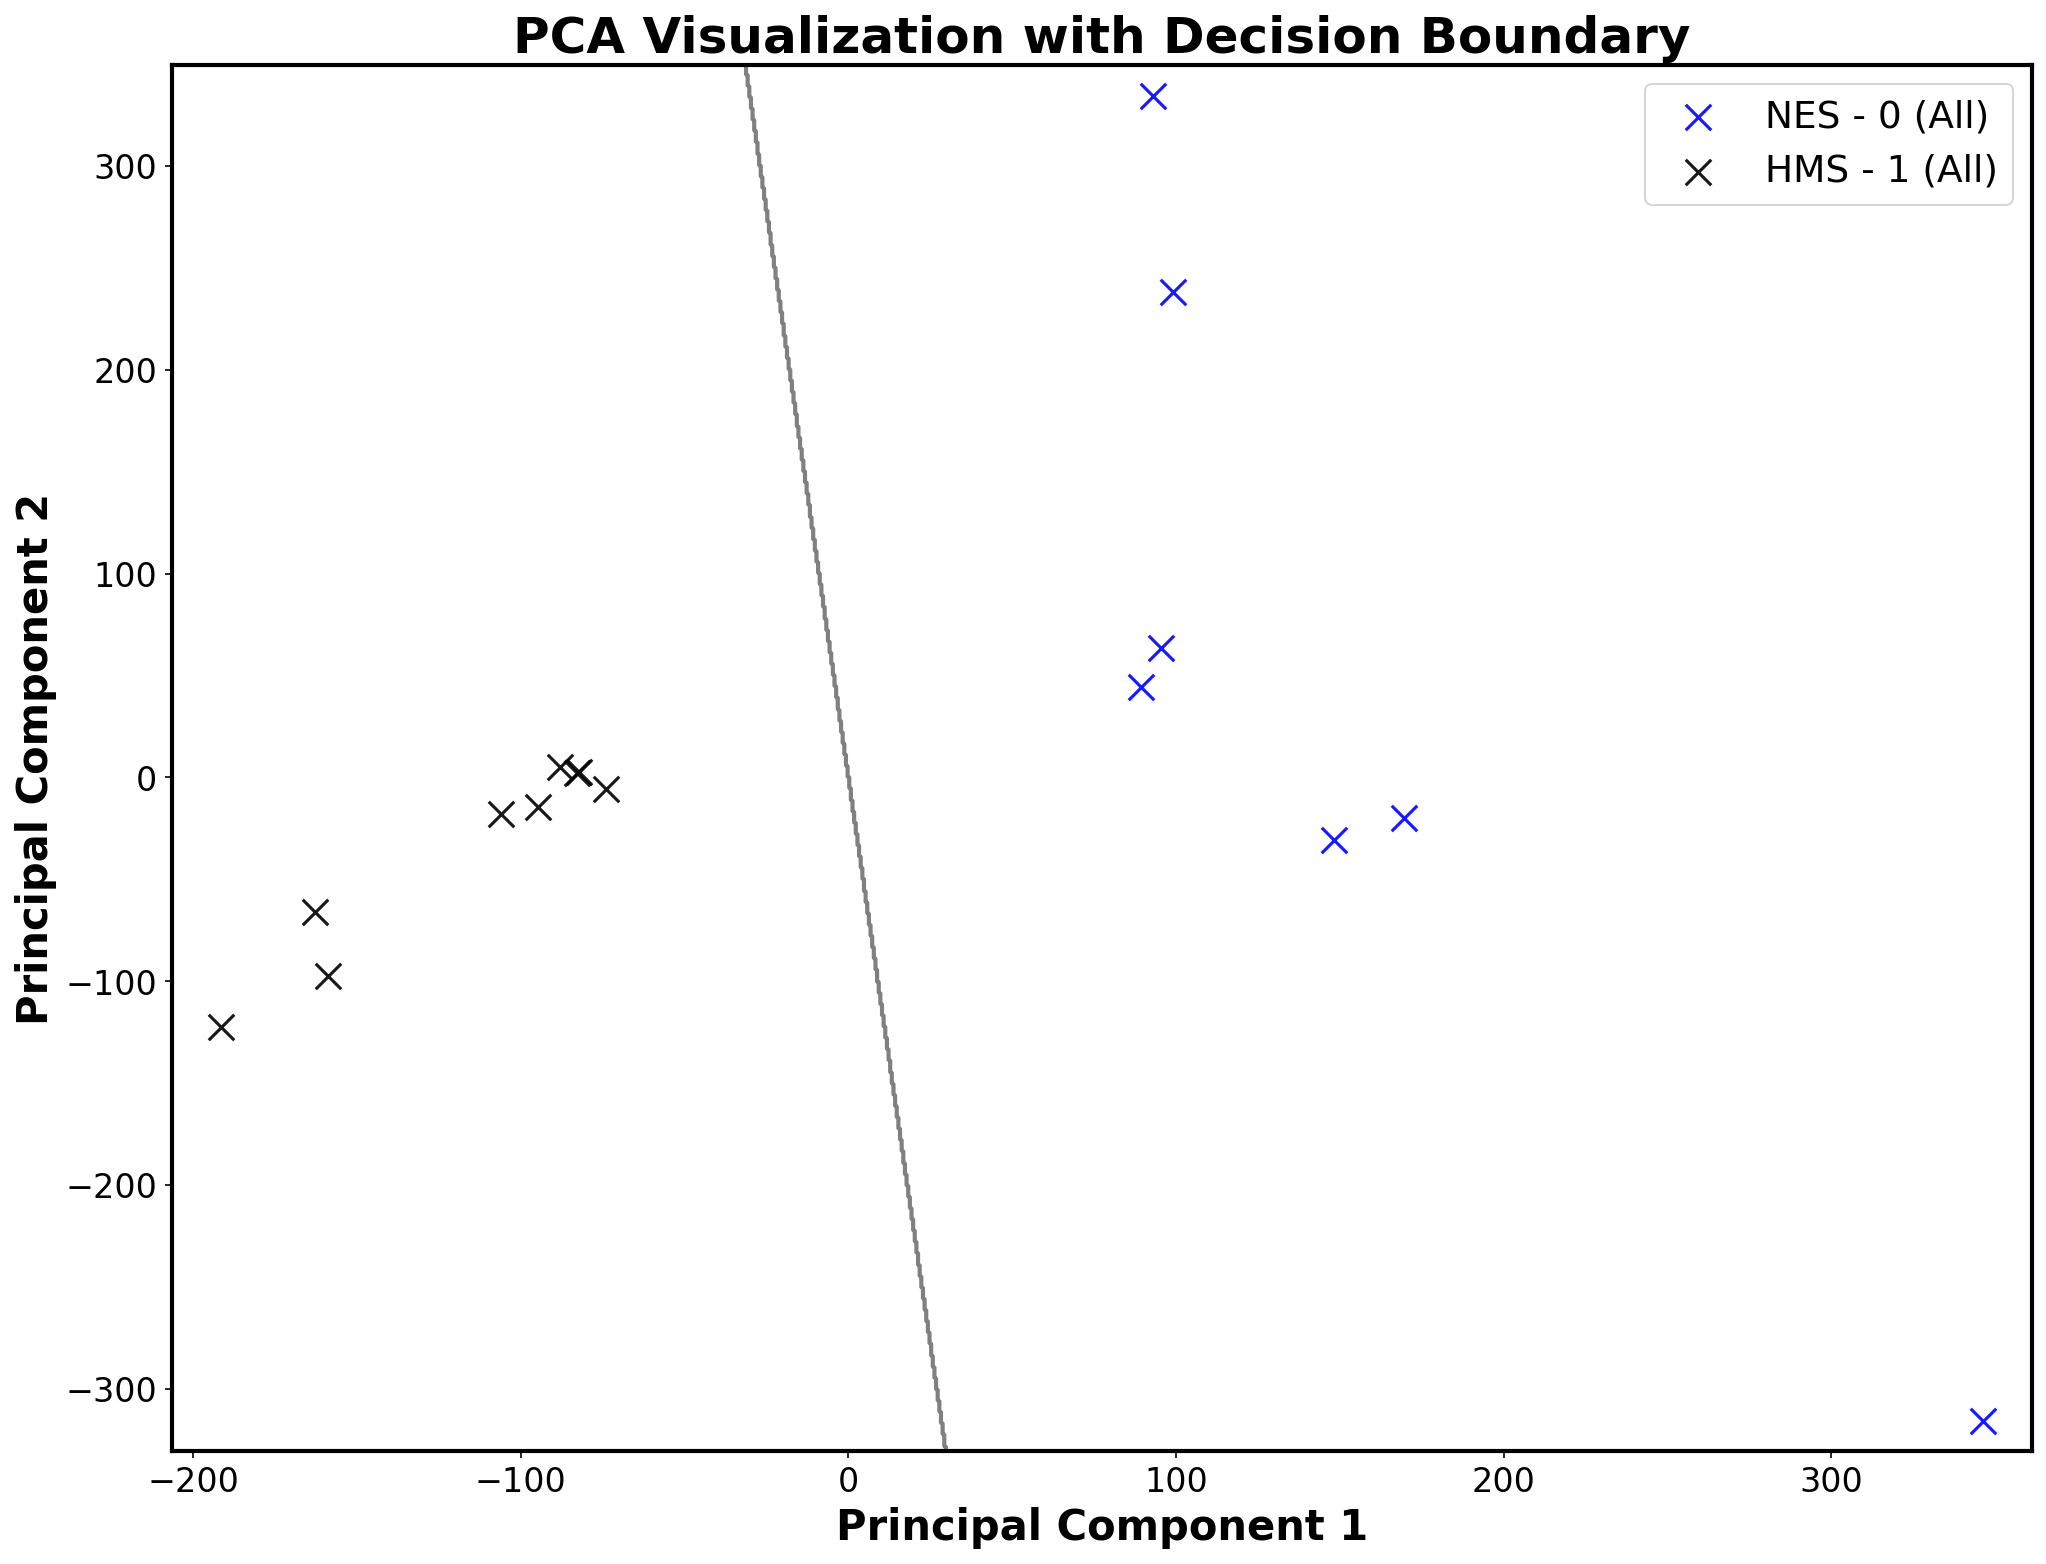

In [54]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Perform PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Map train and test indices to boolean masks
train_indices_bool = np.isin(indices, train_indices)
test_indices_bool = np.isin(indices, test_indices)

# Separate PCA-reduced train and test data
X_pca_train = X_pca[train_indices_bool]
X_pca_test = X_pca[test_indices_bool]
Y_train_subset = Y[train_indices_bool]
Y_test_subset = Y[test_indices_bool]

# Identify misclassified samples within the test set
misclassified_test_indices = np.where((Y_test_subset != Y_pred_classes.flatten()))[0]
misclassified_pca = X_pca_test[misclassified_test_indices]

# Create a mesh grid for the decision boundary
x_min, x_max = X_pca[:, 0].min() - 15, X_pca[:, 0].max() + 15  # Extend range significantly
y_min, y_max = X_pca[:, 1].min() - 15, X_pca[:, 1].max() + 15
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                     np.arange(y_min, y_max, 0.5))

# Train a classifier (e.g., Logistic Regression) for decision boundary
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_pca, Y)  # Combine train and test for the boundary

# Predict the decision boundary
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary with a fully white background
fig, ax = plt.subplots(figsize=(16, 12), dpi=150)  # HD resolution with larger figure
ax.contour(xx, yy, Z, levels=[0.5], colors='gray', linewidths=2)  # Decision boundary as a clean gray line

# Set the entire plot and surrounding area to white
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot all WED (0) samples (train and test)
ax.scatter(
    X_pca[Y == 0, 0], X_pca[Y == 0, 1],
    color='blue', marker='x', label='NES - 0 (All)', alpha=0.9, s=150
)

# Plot all HMS (1) samples (train and test)
ax.scatter(
    X_pca[Y == 1, 0], X_pca[Y == 1, 1],
    color='black', marker='x', label='HMS - 1 (All)', alpha=0.9, s=150
)




# Add a box boundary around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')  # Set the color of the box boundary
    spine.set_linewidth(2)        # Set the width of the box boundary

# Add title, labels, and legend with larger font sizes
ax.set_title('PCA Visualization with Decision Boundary', fontsize=24, weight='bold')
ax.set_xlabel('Principal Component 1', fontsize=20, weight='bold')
ax.set_ylabel('Principal Component 2', fontsize=20, weight='bold')
ax.legend(fontsize=18, loc='upper right')

# Make tick labels larger
ax.tick_params(axis='both', which='major', labelsize=16)

# Set explicit plot range
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Save the plot as a high-resolution image
plt.savefig("PCA_Visualization_HD.png", dpi=300, bbox_inches='tight', facecolor='white')  # Save with a white background

# Show the plot
plt.show()


**NES VS WED WITH CHROMOSOME**

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3750 - loss: 0.9866 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 3.6391e-05 - val_precision_6: 1.0000 - val_recall_6: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - accuracy: 1.0000 - loss: 1.1336e-16 - precision_6: 1.0000 - recall_6: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.5014e-08 - val_precision_6: 1.0000 - val_recall_6: 1.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step - accuracy: 1.0000 - loss: 2.7088e-21 - precision_6: 1.0000 - recall_6: 1.0000 - val_accuracy: 1.0000 - val_loss: 4.2791e-11 - val_precision_6: 1.0000 - val_recall_6: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 1.0000 - loss: 3.6291e-33 - precision_6: 1.0000 - recall_6: 1.0000 - val_accuracy: 1.0000 - val_loss: 3.9894e-13 - val_precision_6: 1.0000 - val_recall_6: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - accuracy: 1.0000 - loss: 2.7009e-14 - precisio

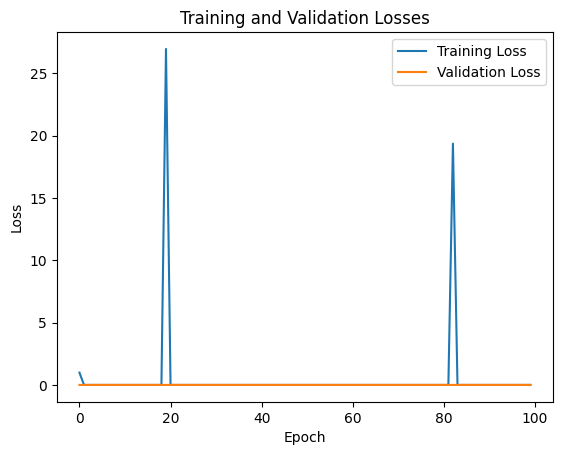

[[1 0]
 [0 4]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [61]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES_VS_WED(ch)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


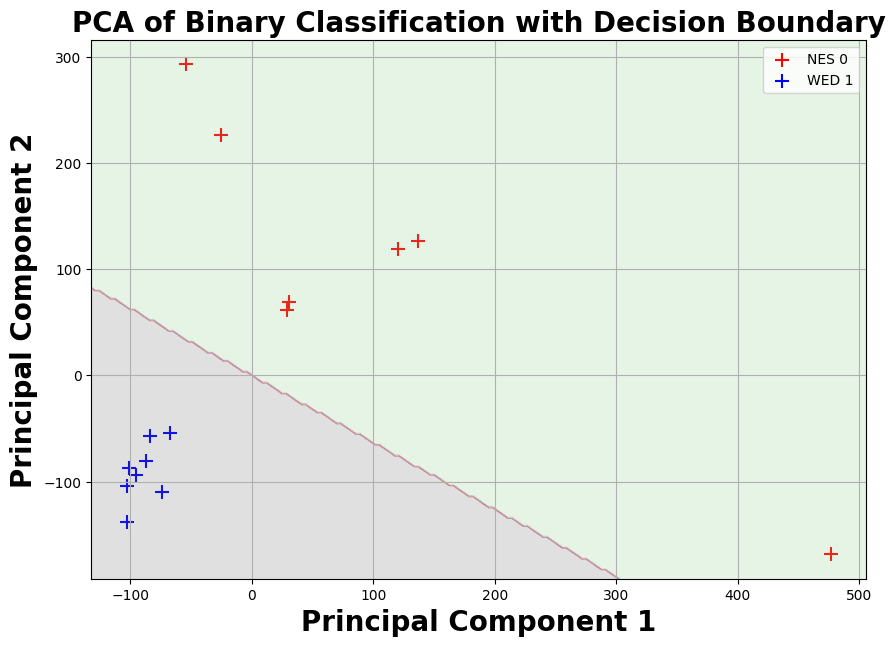

Explained variance ratio by each principal component:
[0.10373331 0.08618986]
Principal components (loadings):
     Scaffold_1.42470  Scaffold_1.42483  Scaffold_1.42490  Scaffold_1.42491  \
PC1          0.003120         -0.000645          0.000403          0.000309   
PC2         -0.000639          0.004263          0.001003          0.000894   

     Scaffold_1.42492  Scaffold_1.42494  Scaffold_1.42505  Scaffold_1.42507  \
PC1          0.001786          0.000956          0.003633          0.001276   
PC2          0.000424          0.001180          0.001718          0.003672   

     Scaffold_1.42510  Scaffold_1.42512  ...  Scaffold_Y.2625977  \
PC1          0.001350          0.000997  ...           -0.002314   
PC2         -0.001112          0.001236  ...           -0.000321   

     Scaffold_Y.2625978  Scaffold_Y.2625990  Scaffold_Y.2625999  \
PC1           -0.000659           -0.001609           -0.002496   
PC2           -0.000532            0.000840           -0.000184   

     S

In [63]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Apply PCA to the features
pca = PCA(n_components=2)  # Use 2 components for visualization
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with PCA results and the target variable
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Classification'] = Y

# Train a Logistic Regression model on the PCA components
lr = LogisticRegression()
lr.fit(X_pca, Y)

# Plot the principal components, color-coded by the binary classes
plt.figure(figsize=(10, 7))
for class_value, label, color in zip(pca_df['Classification'].unique(), ['NES 0', 'WED 1'], ['red', 'blue']):
    subset = pca_df[pca_df['Classification'] == class_value]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, color=color, marker='+', s=100)

# Plot decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 200), np.linspace(ylim[0], ylim[1], 200))
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.2, cmap='Accent')
plt.xlabel('Principal Component 1', fontsize=20, weight='bold')
plt.ylabel('Principal Component 2', fontsize=20, weight='bold')
plt.title('PCA of Binary Classification with Decision Boundary', fontsize=20, weight='bold')
plt.legend()
plt.grid()

# Save the plot with a white background and high DPI
plt.savefig('/content/PCA_decision_boundary.png', dpi=300, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

# Print explained variance ratio
print("Explained variance ratio by each principal component:")
print(pca.explained_variance_ratio_)

# Mapping the principal components to original feature names
feature_names = data.drop(columns=[target_column]).columns
components_df = pd.DataFrame(pca.components_, columns=feature_names, index=['PC1', 'PC2'])

# Display the principal components dataframe
print("Principal components (loadings):")
print(components_df)

# Save the principal components to a CSV file if needed
components_df.to_csv('/content/principal_components_loadings.csv', index=True)


**NES VS WED WITHOUT XY**

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.9676 - precision_9: 1.0000 - recall_9: 0.2000 - val_accuracy: 0.5000 - val_loss: 0.5711 - val_precision_9: 0.0000e+00 - val_recall_9: 0.0000e+00
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step - accuracy: 1.0000 - loss: 5.2950e-04 - precision_9: 1.0000 - recall_9: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.5137 - val_precision_9: 0.0000e+00 - val_recall_9: 0.0000e+00
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step - accuracy: 1.0000 - loss: 4.9448e-30 - precision_9: 1.0000 - recall_9: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.4514 - val_precision_9: 0.0000e+00 - val_recall_9: 0.0000e+00
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step - accuracy: 1.0000 - loss: 1.2263e-25 - precision_9: 1.0000 - recall_9: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.4028 - val_precision_9: 0.0000e+00 - val_recall_9: 0.0000e+00
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - 

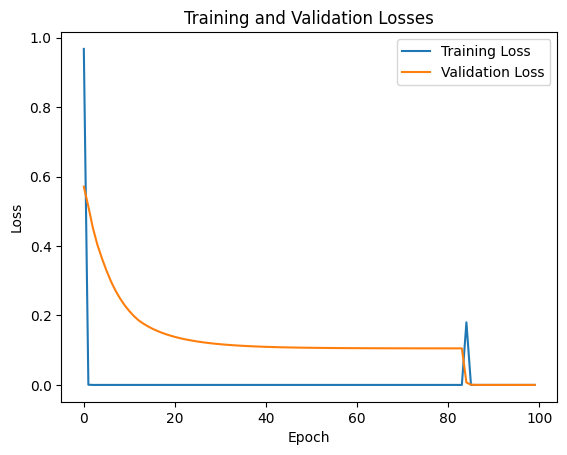

[[3 0]
 [0 2]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         3
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [66]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES_VS_WED(wxy)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


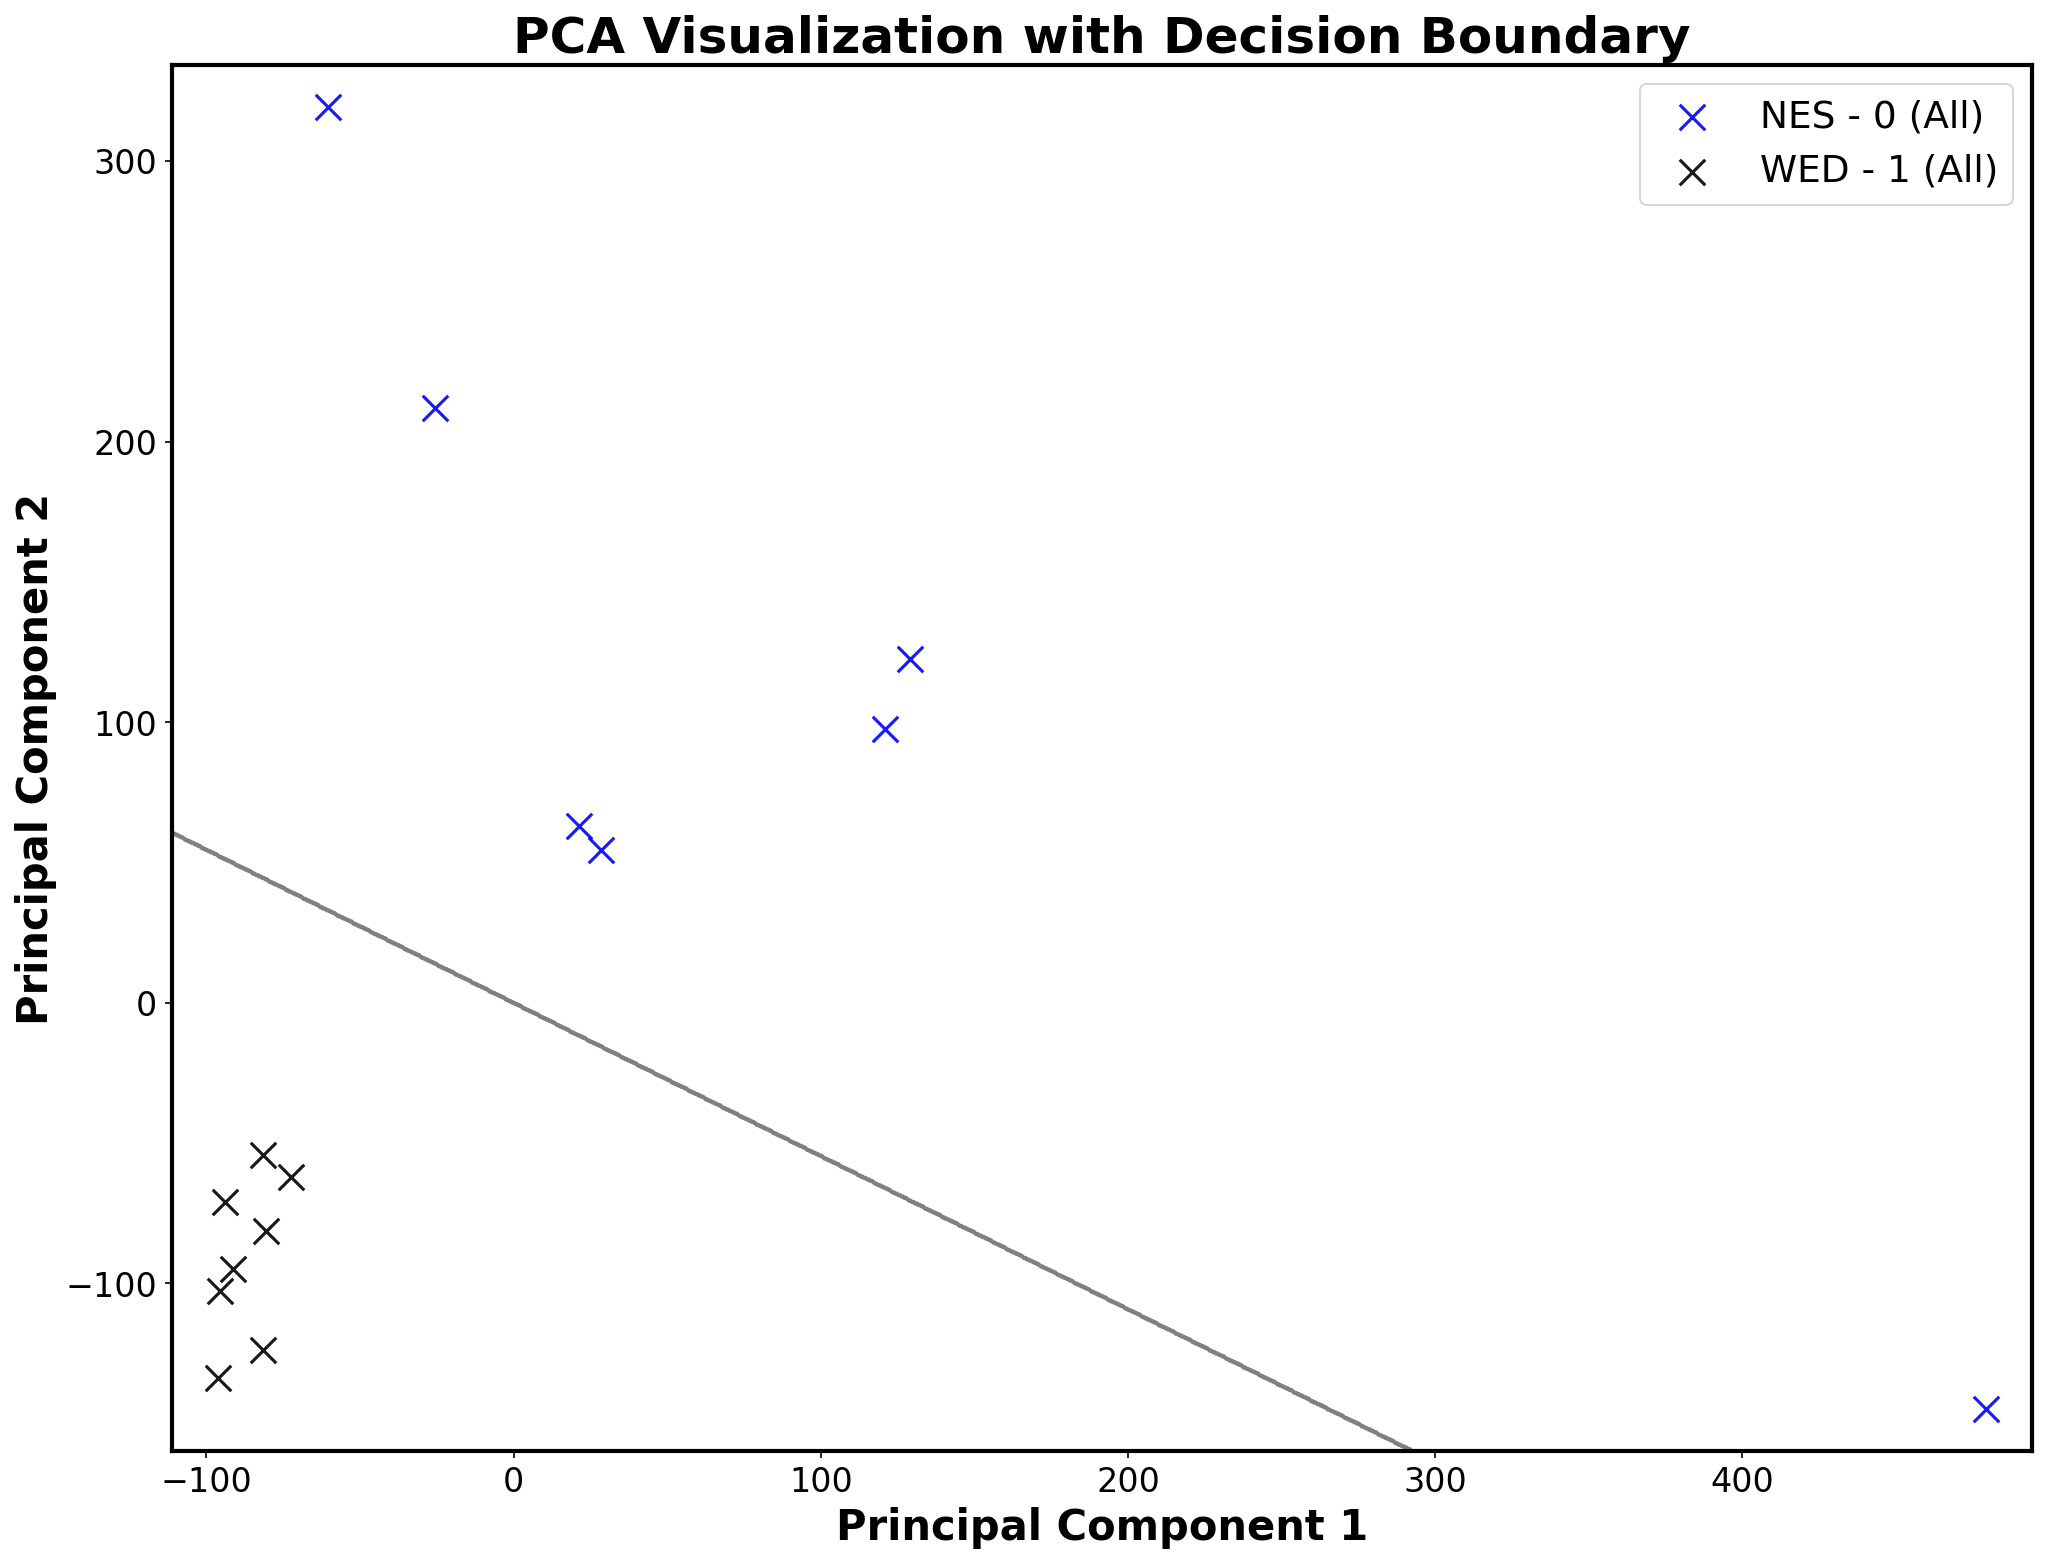

In [68]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Perform PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Map train and test indices to boolean masks
train_indices_bool = np.isin(indices, train_indices)
test_indices_bool = np.isin(indices, test_indices)

# Separate PCA-reduced train and test data
X_pca_train = X_pca[train_indices_bool]
X_pca_test = X_pca[test_indices_bool]
Y_train_subset = Y[train_indices_bool]
Y_test_subset = Y[test_indices_bool]

# Identify misclassified samples within the test set
misclassified_test_indices = np.where((Y_test_subset != Y_pred_classes.flatten()))[0]
misclassified_pca = X_pca_test[misclassified_test_indices]

# Create a mesh grid for the decision boundary
x_min, x_max = X_pca[:, 0].min() - 15, X_pca[:, 0].max() + 15  # Extend range significantly
y_min, y_max = X_pca[:, 1].min() - 15, X_pca[:, 1].max() + 15
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                     np.arange(y_min, y_max, 0.5))

# Train a classifier (e.g., Logistic Regression) for decision boundary
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_pca, Y)  # Combine train and test for the boundary

# Predict the decision boundary
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary with a fully white background
fig, ax = plt.subplots(figsize=(16, 12), dpi=150)  # HD resolution with larger figure
ax.contour(xx, yy, Z, levels=[0.5], colors='gray', linewidths=2)  # Decision boundary as a clean gray line

# Set the entire plot and surrounding area to white
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot all WED (0) samples (train and test)
ax.scatter(
    X_pca[Y == 0, 0], X_pca[Y == 0, 1],
    color='blue', marker='x', label='NES - 0 (All)', alpha=0.9, s=150
)

# Plot all HMS (1) samples (train and test)
ax.scatter(
    X_pca[Y == 1, 0], X_pca[Y == 1, 1],
    color='black', marker='x', label='WED - 1 (All)', alpha=0.9, s=150
)




# Add a box boundary around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')  # Set the color of the box boundary
    spine.set_linewidth(2)        # Set the width of the box boundary

# Add title, labels, and legend with larger font sizes
ax.set_title('PCA Visualization with Decision Boundary', fontsize=24, weight='bold')
ax.set_xlabel('Principal Component 1', fontsize=20, weight='bold')
ax.set_ylabel('Principal Component 2', fontsize=20, weight='bold')
ax.legend(fontsize=18, loc='upper right')

# Make tick labels larger
ax.tick_params(axis='both', which='major', labelsize=16)

# Set explicit plot range
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Save the plot as a high-resolution image
plt.savefig("PCA_Visualization_HD.png", dpi=300, bbox_inches='tight', facecolor='white')  # Save with a white background

# Show the plot
plt.show()


**NES VS HMS VS WED with choromosome**

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2500 - loss: 1.8176 - val_accuracy: 0.7500 - val_loss: 1.2941
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9167 - loss: 0.2214 - val_accuracy: 0.7500 - val_loss: 3.0367
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.7500 - val_loss: 4.1767
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.7500 - val_loss: 4.9554
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8333 - loss: 10.3862 - val_accuracy: 0.7500 - val_loss: 4.6216
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9167 - loss: 5.4583 - val_accuracy: 0.7500 - val_loss: 4.1631
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.7500 - val_loss: 3.9203
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9167 - loss: 0.7178 - val_accuracy: 0.7500 

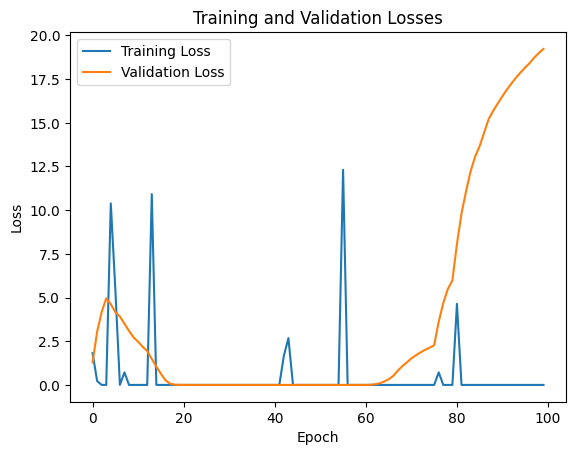

Confusion Matrix:
[[2 0 2]
 [0 1 0]
 [0 0 3]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1       1.00      1.00      1.00         1
           2       0.60      1.00      0.75         3

    accuracy                           0.75         8
   macro avg       0.87      0.83      0.81         8
weighted avg       0.85      0.75      0.74         8



In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from tensorflow.keras.utils import to_categorical

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES_VS_HMS_VS_WED(ch)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('int')  # Convert to integers for classification

# One-hot encode the target variable
Y_categorical = to_categorical(Y, num_classes=3)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y_categorical, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # Use softmax for multi-class classification
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Use categorical crossentropy
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)  # Convert predictions to class indices
Y_test_classes = np.argmax(Y_test, axis=1)  # Convert one-hot test labels to class indices

# Compute overall precision, recall, and F1-score
precision = precision_score(Y_test_classes, Y_pred_classes, average='weighted')
recall = recall_score(Y_test_classes, Y_pred_classes, average='weighted')
overall_accuracy = accuracy_score(Y_test_classes, Y_pred_classes)

print(f"Overall Precision: {precision}")
print(f"Overall Recall: {recall}")
print(f"Overall Accuracy: {overall_accuracy}")

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test_classes,
    'Predicted': Y_pred_classes
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions_multiclass.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(Y_test_classes, Y_pred_classes))
print("Classification Report:")
print(classification_report(Y_test_classes, Y_pred_classes))


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


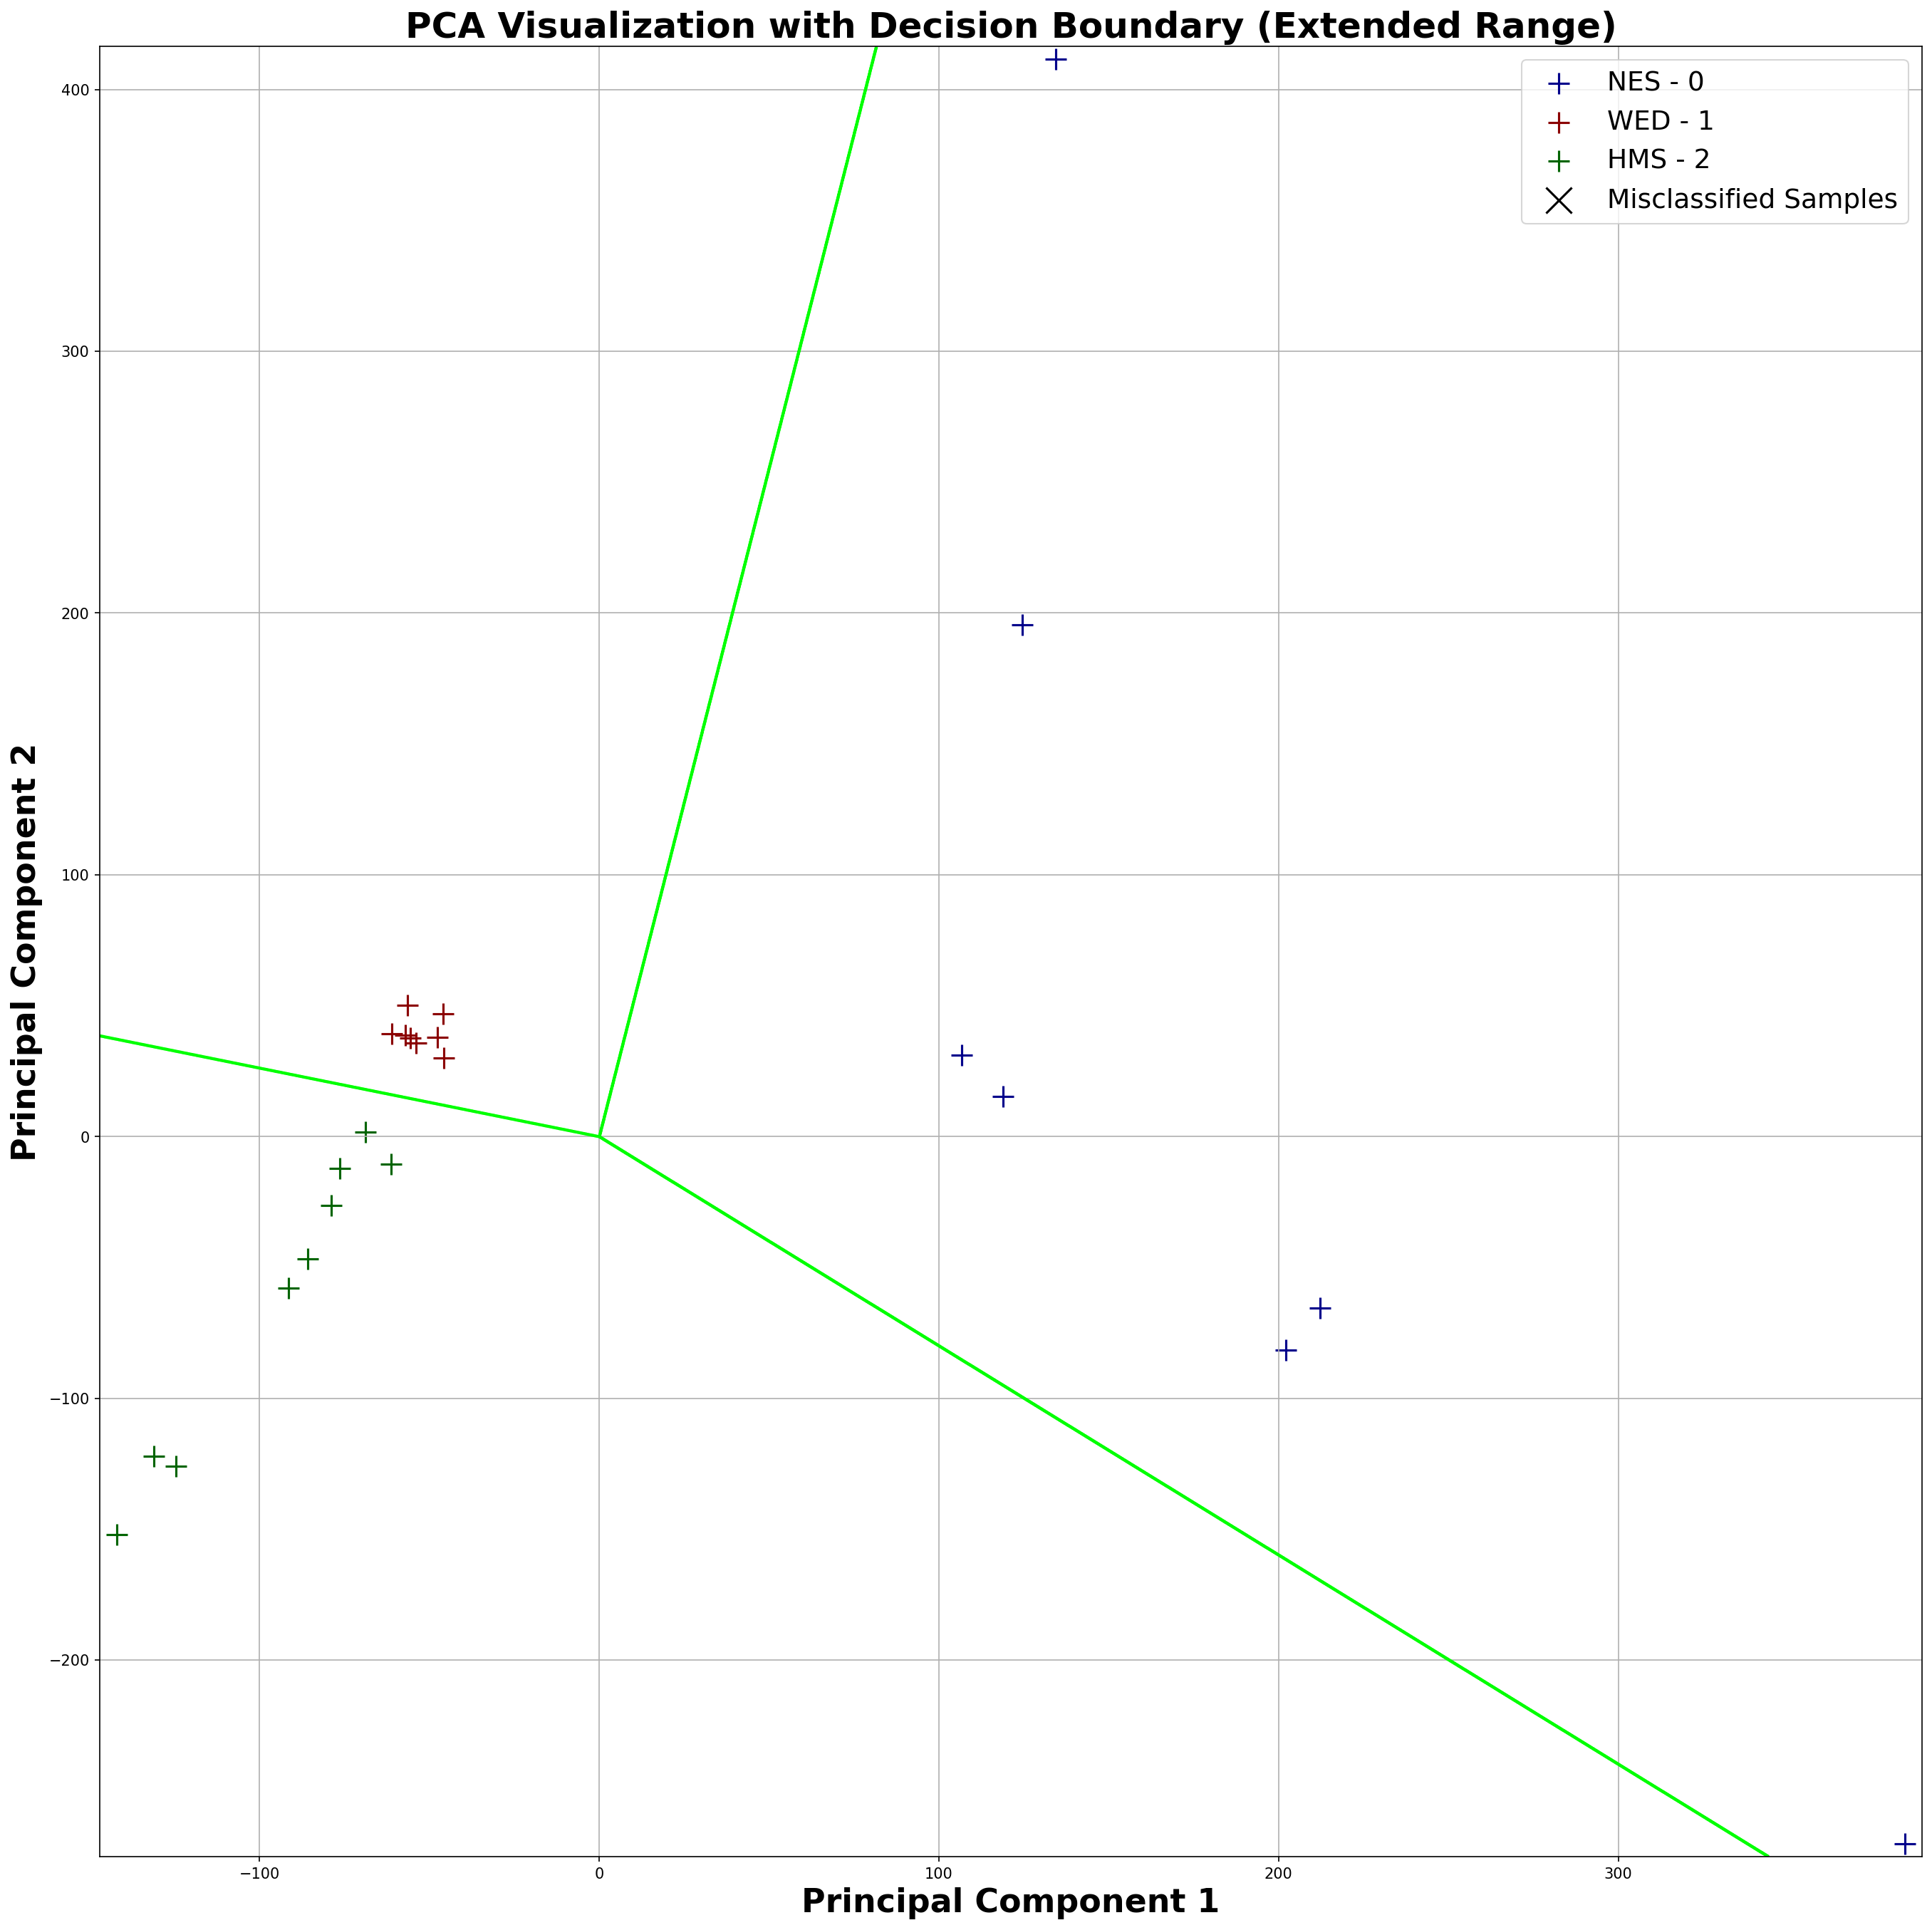

In [18]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# Perform PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Use the full dataset for PCA and classification
Y_classes = Y  # Directly use Y as it already contains class labels (0, 1, 2)

# Train a classifier (e.g., Logistic Regression) on the full dataset
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(max_iter=1000, multi_class='multinomial')
classifier.fit(X_pca, Y_classes)

# Predict classes for the entire dataset
Y_pred_classes = classifier.predict(X_pca)

# Identify misclassified samples
misclassified_mask = Y_classes != Y_pred_classes
misclassified_samples = indices[misclassified_mask]  # Sample names
misclassified_pca = X_pca[misclassified_mask]

# Create a mesh grid for the decision boundary
x_min, x_max = X_pca[:, 0].min() - 5, X_pca[:, 0].max() + 5  # Increase axis range
y_min, y_max = X_pca[:, 1].min() - 5, X_pca[:, 1].max() + 5  # Increase axis range
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),  # Larger step size for efficiency
                     np.arange(y_min, y_max, 0.1))

# Predict the decision boundary
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = classifier.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot the decision boundary as lines
plt.figure(figsize=(22, 22), dpi=150)
plt.contour(xx, yy, Z, levels=[0.5, 1.5, 2.5], colors='lime', linewidths=2)  # Thicker boundary lines

# Set the background color to white
plt.gca().set_facecolor('white')

# Plot NES (0), WED (1), and HMS (2) for the combined dataset
plt.scatter(
    X_pca[Y_classes == 0, 0], X_pca[Y_classes == 0, 1],
    color='darkblue', marker='+', label='NES - 0', alpha=1.0, s=200  # Darker color, larger size
)
plt.scatter(
    X_pca[Y_classes == 1, 0], X_pca[Y_classes == 1, 1],
    color='darkred', marker='+', label='WED - 1', alpha=1.0, s=200  # Darker color, larger size
)
plt.scatter(
    X_pca[Y_classes == 2, 0], X_pca[Y_classes == 2, 1],
    color='darkgreen', marker='+', label='HMS - 2', alpha=1.0, s=200  # Darker color, larger size
)

# Highlight misclassified samples with red crosses
plt.scatter(
    misclassified_pca[:, 0], misclassified_pca[:, 1],
    color='black', marker='x', label='Misclassified Samples', s=300  # Larger misclassified points
)

# Add title, labels, and legend
plt.title('PCA Visualization with Decision Boundary (Extended Range)', fontsize=24, weight='bold')
plt.xlabel('Principal Component 1', fontsize=22, weight='bold')
plt.ylabel('Principal Component 2', fontsize=22, weight='bold')
plt.legend(fontsize=18)
plt.grid()

# Extend axis range for better visualization
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Show the plot
plt.show()


NES VS WED VS HMS WITHOUT XY

Epoch 1/150


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 2.2950 - val_accuracy: 0.7500 - val_loss: 0.5859
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.6667 - loss: 9.7933 - val_accuracy: 0.7500 - val_loss: 1.1102
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9167 - loss: 1.9320 - val_accuracy: 0.7500 - val_loss: 1.3313
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.7500 - val_loss: 1.4051
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.8333 - loss: 0.5783 - val_accuracy: 0.7500 - val_loss: 1.4323
Epoch 6/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9167 - loss: 9.6125 - val_accuracy: 0.7500 - val_loss: 1.1926
Epoch 7/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.7500 - val_loss: 0.9068
Epoch 8/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8333 - loss: 14.1639 - val_accuracy: 0.7500 - val_los

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


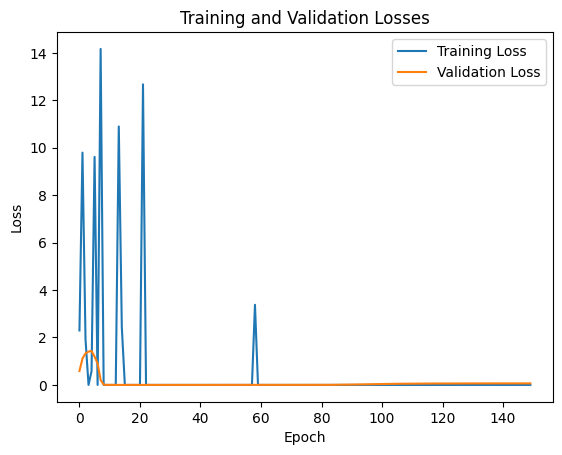

Confusion Matrix:
[[3 0 0]
 [0 0 2]
 [0 0 3]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.00      0.00      0.00         2
           2       0.60      1.00      0.75         3

    accuracy                           0.75         8
   macro avg       0.53      0.67      0.58         8
weighted avg       0.60      0.75      0.66         8



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from tensorflow.keras.utils import to_categorical

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES_VS_HMS_VS_WED(wxy)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('int')  # Convert to integers for classification

# One-hot encode the target variable
Y_categorical = to_categorical(Y, num_classes=3)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y_categorical, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # Use softmax for multi-class classification
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Use categorical crossentropy
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, Y_train, epochs=150, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)  # Convert predictions to class indices
Y_test_classes = np.argmax(Y_test, axis=1)  # Convert one-hot test labels to class indices

# Compute overall precision, recall, and F1-score
precision = precision_score(Y_test_classes, Y_pred_classes, average='weighted')
recall = recall_score(Y_test_classes, Y_pred_classes, average='weighted')
overall_accuracy = accuracy_score(Y_test_classes, Y_pred_classes)

print(f"Overall Precision: {precision}")
print(f"Overall Recall: {recall}")
print(f"Overall Accuracy: {overall_accuracy}")

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test_classes,
    'Predicted': Y_pred_classes
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions_multiclass.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(Y_test_classes, Y_pred_classes))
print("Classification Report:")
print(classification_report(Y_test_classes, Y_pred_classes))


**Tissue VS MUscle with xy**

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 2.2927 - precision_3: 0.3333 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 5.8800e-06 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 3.9203e-41 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 1.3886e-14 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_3: 1.0000 - recall_3: 

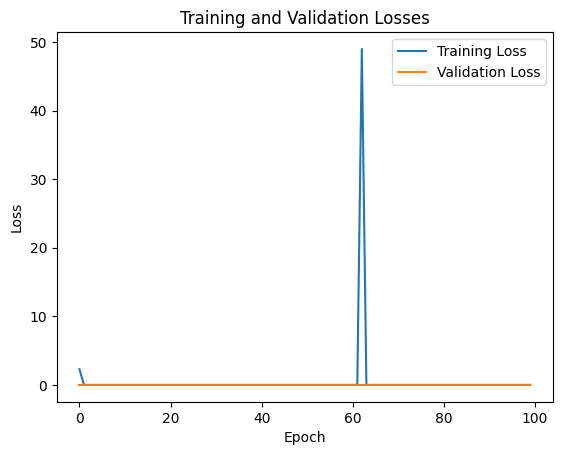

[[3]]
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [26]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/Tissues_VS_Muscle(ch)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


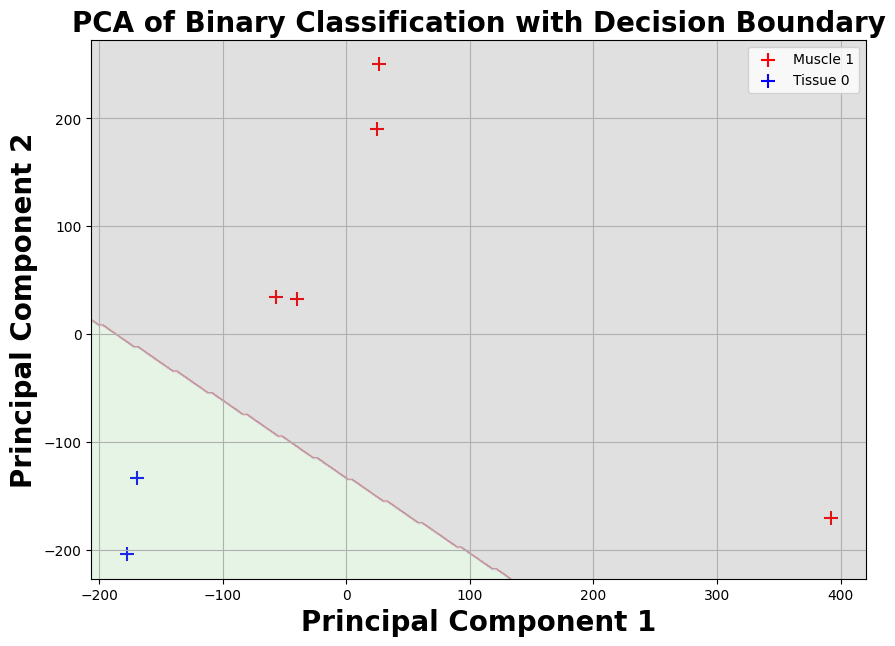

Explained variance ratio by each principal component:
[0.20743029 0.17828275]
Principal components (loadings):
     Scaffold_1.42470  Scaffold_1.42483  Scaffold_1.42490  Scaffold_1.42491  \
PC1          0.003679         -0.002196         -0.000733         -0.000515   
PC2          0.001895         -0.002014          0.000522          0.000492   

     Scaffold_1.42492  Scaffold_1.42494  Scaffold_1.42505  Scaffold_1.42507  \
PC1          0.001073          0.000621          0.002145         -0.000988   
PC2          0.000009          0.002953         -0.002008          0.001227   

     Scaffold_1.42510  Scaffold_1.42512  ...  Scaffold_Y.2625965  \
PC1          0.001997          0.000341  ...           -0.000335   
PC2         -0.000643          0.003778  ...           -0.001194   

     Scaffold_Y.2625977  Scaffold_Y.2625978  Scaffold_Y.2625990  \
PC1           -0.002196           -0.000733           -0.002308   
PC2           -0.002014            0.000522           -0.003076   

     S

In [28]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Apply PCA to the features
pca = PCA(n_components=2)  # Use 2 components for visualization
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame with PCA results and the target variable
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Classification'] = Y

# Train a Logistic Regression model on the PCA components
lr = LogisticRegression()
lr.fit(X_pca, Y)

# Plot the principal components, color-coded by the binary classes
plt.figure(figsize=(10, 7))
for class_value, label, color in zip(pca_df['Classification'].unique(), ['Muscle 1', 'Tissue 0'], ['red', 'blue']):
    subset = pca_df[pca_df['Classification'] == class_value]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, color=color, marker='+', s=100)

# Plot decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 200), np.linspace(ylim[0], ylim[1], 200))
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.2, cmap='Accent')
plt.xlabel('Principal Component 1', fontsize=20, weight='bold')
plt.ylabel('Principal Component 2', fontsize=20, weight='bold')
plt.title('PCA of Binary Classification with Decision Boundary', fontsize=20, weight='bold')
plt.legend()
plt.grid()

# Save the plot with a white background and high DPI
plt.savefig('/content/PCA_decision_boundary.png', dpi=300, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

# Print explained variance ratio
print("Explained variance ratio by each principal component:")
print(pca.explained_variance_ratio_)

# Mapping the principal components to original feature names
feature_names = data.drop(columns=[target_column]).columns
components_df = pd.DataFrame(pca.components_, columns=feature_names, index=['PC1', 'PC2'])

# Display the principal components dataframe
print("Principal components (loadings):")
print(components_df)

# Save the principal components to a CSV file if needed
components_df.to_csv('/content/principal_components_loadings.csv', index=True)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 1.0516 - precision_3: 0.3333 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.6650e-13 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 1.0000 - loss: 1.6786e-19 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 8.0273e-22 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 9.6704e-28 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 1.0000 - val_loss: 2.9317e-32 - val_precision_3: 1.0000 - val_recall_3: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 6.0164e-07 - precision_3: 1.0000 - recall

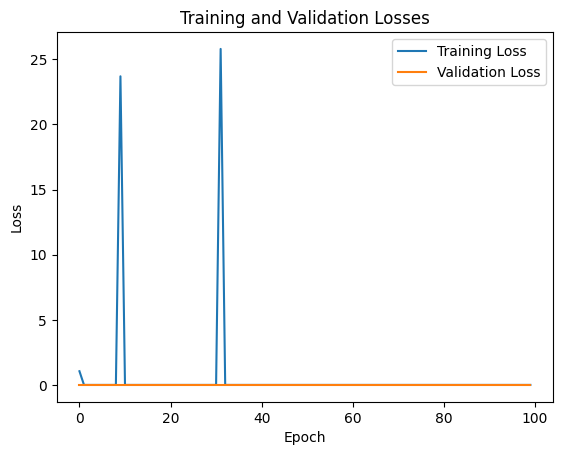

[[3]]
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/Tissues_VS_Muscle(wxy)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_scaled, Y, indices, test_size=0.3, shuffle=True
)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))
